## Experiment Workflow

In [17]:
# Adjust if your VS Code kernel needs help finding pip / scripts
import os
# python_path = r"C:\Users\QT3 User Facility\AppData\Local\Programs\Python\Python314\Scripts"
# os.environ["PATH"] = python_path + ";" + os.environ["PATH"]

!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [18]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
from copy import copy
from scipy.optimize import curve_fit
import qickdawg as qd
from importlib.metadata import version

import sys, os
sys.path.insert(0, os.path.abspath('..'))

print(f"numpy     {version('numpy')}")
print(f"qickdawg  {version('qickdawg')}")
print(f"python    {sys.version}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
numpy     1.26.4
qickdawg  1.2.1
python    3.11.15 (main, Apr 14 2026, 14:31:26) [MSC v.1944 64 bit (AMD64)]


<a id="connect"></a>
### Connect to board

In [19]:
qd.start_client('192.168.3.1')
print("Connected — soccfg loaded:", qd.soccfg is not None)

Connected — soccfg loaded: True


In [20]:
default_config = qd.NVConfiguration()

default_config.adc_channel              = 0
default_config.mw_channel               = 0
default_config.mw_nqz                   = 1
default_config.mw_gain                  = 1800
default_config.laser_gate_pmod          = 0
default_config.laser_on_tus             = 2
default_config.laser_readout_offset_tus = 1.172
default_config.readout_integration_tns  = 300
default_config.mw_laser_delay_treg      = 0
default_config.relax_delay_tus          = 1.1
default_config.pre_init                 = True
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500

In [21]:
default_config.one_treg = 1
default_config.one_tns

3.2552083333333335

<a id="top"></a>
# Table of Contents
1. [Connect to board](#connect)
2. [Laser](#laser)
3. [Counting Duration](#cd)
3. [PODMR](#podmr)
4. [RABI](#rabi)
5. [Ramsey](#ramsey)
6. [Hahn Echo](#hahn-echo)
7. [CPMG](#cpmg)
8. [CPMG Reopt Loop](#cpmg-reopt)

<a id="laser"></a>
### Laser
[Back to top](#top)

In [24]:
# Expected: laser should illuminate the sample
qd.laser_on(copy(default_config))

1

In [25]:
# Expected: laser should turn off
qd.laser_off(copy(default_config))

0

### PL counts — live scope

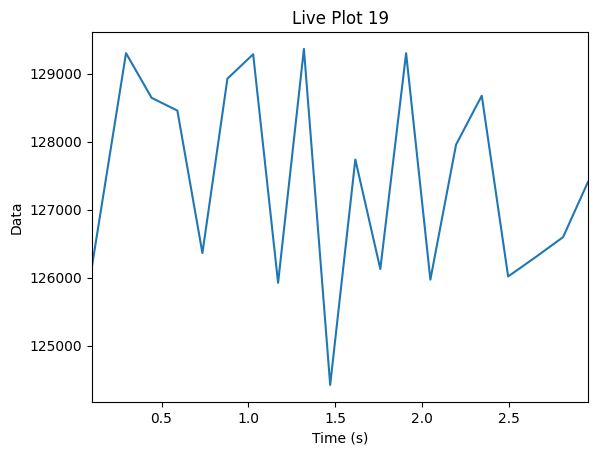

In [8]:
config = copy(default_config)
config.readout_integration_treg = 2**16 - 1
config.reps = 300
config.relax_delay_tns = 0

prog = qd.PLIntensity(config)

def get_cps():
    d = prog.acquire(progress=False)
    return d / (config.readout_integration_tus * 1e-6 * config.reps)

qd.live_plot(get_cps)

<a id="cd"></a>
### Counting Duration

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.14 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.
[counting_duration] Sweep: 151 points from 1000 to 2500 ns
[counting_duration] Reps: 300000, Integration: 10 ns
[counting_duration] Transition: lower_dip


Counting-duration sweep: 100%|██████████| 151/151 [13:07<00:00,  5.21s/step, offset_ns=2500, done=151/151]

[counting_duration] Optimal window: start=1.169 us, duration=0.462 us
[counting_duration] Saved -> C:\Users\QT3 User Facility\Documents\qick-dawg\data\counting_duration\counting_duration_fine_res_20260525_164507.h5


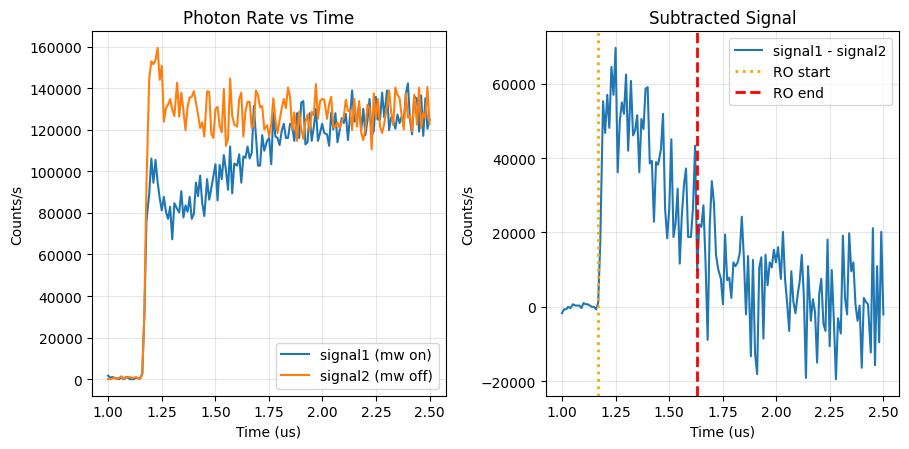

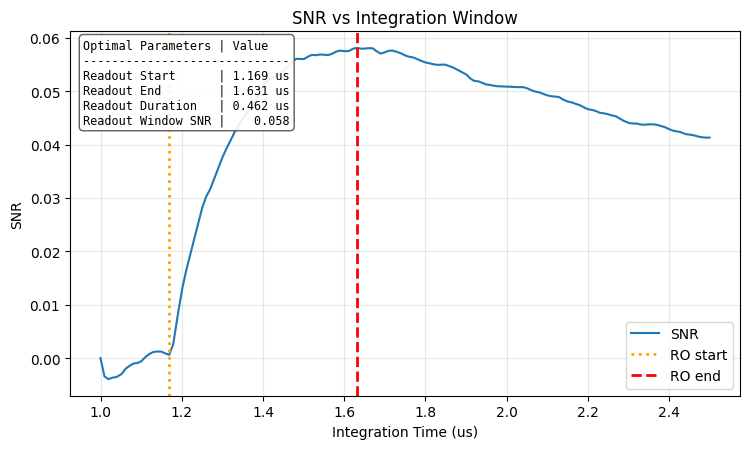

In [14]:
%run ../experiments/legacy/counting_duration.py

<a id="podmr"></a>

### PODMR
Edit parameters in `experiments/run/run_podmr.py` (EXPERIMENT PARAMETERS block), then run this cell.
The script handles connection, sweep config, acquisition, HDF5 save, and plot internally.
Use `%run -i` to inject variable overrides from a prior cell without editing the file.

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.14 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 1833 to 1840 by 0.05
Instead using 1833.0 to 1840.0000534057617 by 0.05000038146972656 in 141 steps
[podmr] Sweep: 1833.000 -> 1840.000 fMHz (delta 0.050 fMHz)
[podmr] Active transition: lower_dip | mw_fMHz=1838.1500003814697 MHz | mw_gain=500
[podmr] pi pulse: override_mw_pi_ftns=2300.0081380208335

Requested 1833 to 1840 by 0.05
Instead using 1833.0 to 1840.0000534057617 by 0.05000038146972656 in 141 steps

Requested 1833 to 1840 by 0.05
Instead using 1833.0 to 1840.0000534057617 by 0.05000038146972656 in 141 steps


100%|██████████| 56400000/56400000 [20:24<00:00, 46066.10it/s]



Requested 1833 to 1840 by 0.05
Instead using 1833.0 to 1840.0000534057617 by 0.05000038146972656 in 141 steps


100%|██████████| 56400000/56400000 [20:24<00:00, 46065.89it/s]



Requested 1833 to 1840 by 0.05
Instead using 1833.0 to 1840.0000534057617 by 0.05000038146972656 in 141 steps


...


Requested 1833 to 1840 by 0.05
Instead using 1833.0 to 1840.0000534057617 by 0.05000038146972656 in 141 steps


100%|██████████| 56400000/56400000 [20:24<00:00, 46066.16it/s]



Requested 1833 to 1840 by 0.05
Instead using 1833.0 to 1840.0000534057617 by 0.05000038146972656 in 141 steps


100%|██████████| 56400000/56400000 [20:24<00:00, 46066.12it/s]


[podmr_fine_res] Chunked run complete: {'run_id': '20260525_131046', 'output_h5_path': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\podmr\\.podmr_fine_res_run_20260525_131046\\podmr_fine_res_20260525_131046.h5', 'output_dir': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\podmr', 'plot_path': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\podmr\\.podmr_fine_res_run_20260525_131046\\podmr_aggregated.png', 'n_chunks_completed': 9}


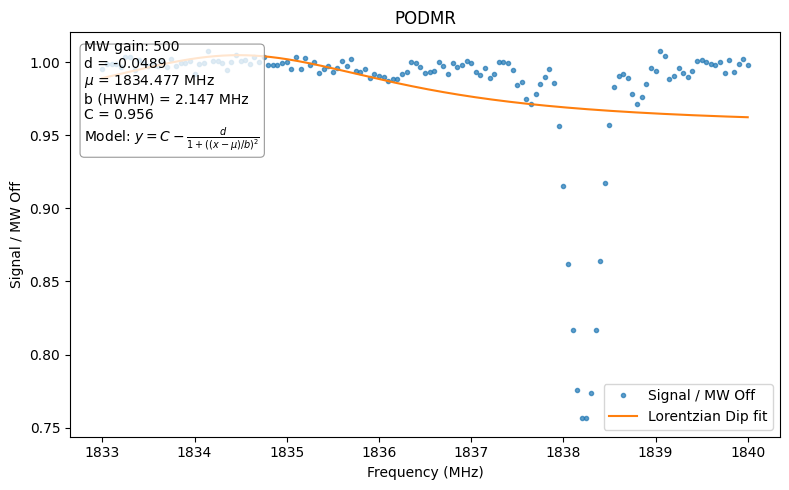

In [59]:
%run ../experiments/run/run_podmr.py

<a id="rabi"></a>

### RABI
Edit parameters in `experiments/run/run_rabi.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.14 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 5 to 500 by 1
Instead using 5.086263020833334 to 508.62630208333337 by 1.0172526041666667 in 496 steps
[rabi] Sweep: 5.000 -> 500.000 ftns (delta 1.000 ftns)
[rabi] Active transition: lower_dip | freq=1838.1500003814697 MHz | gain=32767

Requested 5 to 500 by 1
Instead using 5.086263020833334 to 508.62630208333337 by 1.0172526041666667 in 496 steps

Requested 5 to 500 by 1
Instead using 5.086263020833334 to 508.62630208333337 by 1.0172526041666667 in 496 steps


100%|██████████| 49600000/49600000 [14:34<00:00, 56716.51it/s]



Requested 5 to 500 by 1
Instead using 5.086263020833334 to 508.62630208333337 by 1.0172526041666667 in 496 steps


100%|██████████| 49600000/49600000 [14:34<00:00, 56716.62it/s]



Requested 5 to 500 by 1
Instead using 5.086263020833334 to 508.62630208333337 by 1.0172526041666667 in 496 steps


...


Requested 5 to 500 by 1
Instead using 5.086263020833334 to 508.62630208333337 by 1.0172526041666667 in 496 steps


100%|██████████| 49600000/49600000 [14:34<00:00, 56715.53it/s]



Requested 5 to 500 by 1
Instead using 5.086263020833334 to 508.62630208333337 by 1.0172526041666667 in 496 steps


100%|██████████| 49600000/49600000 [14:34<00:00, 56716.32it/s]


[rabi_fine_res] Chunked run complete: {'run_id': '20260525_104206', 'output_h5_path': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\rabi\\.rabi_fine_res_run_20260525_104206\\rabi_fine_res_20260525_104206.h5', 'output_dir': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\rabi', 'plot_path': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\rabi\\.rabi_fine_res_run_20260525_104206\\rabi_aggregated.png', 'n_chunks_completed': 10}


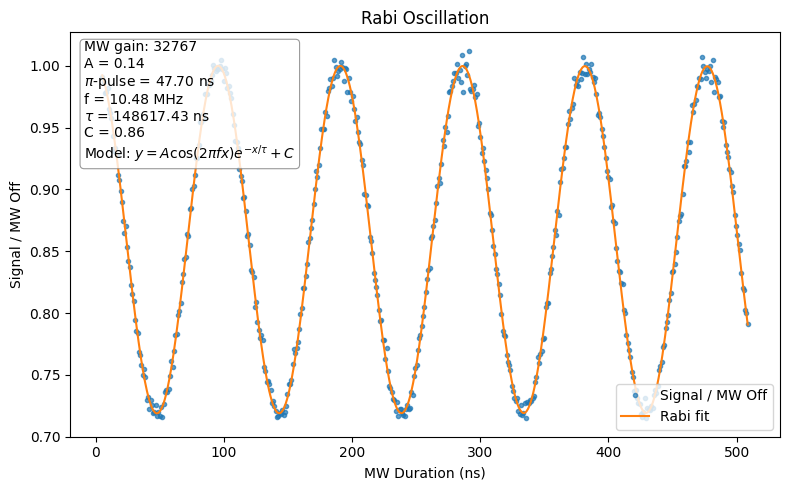

In [58]:
%run ../experiments/run/run_rabi.py

In [61]:
config.e_ftns = 47.7
config.e_ftsamp

234

In [2]:
import h5py, yaml, pprint
p = r"..\data\ramsey\.ramsey_fine_res_run_20260519_165651\ramsey_fine_res_20260519_165651.h5"
with h5py.File(p,'r') as f:
    print("metadata keys:", list(f["metadata"].attrs.keys()))
    cfg_yaml = f["metadata"].attrs.get("config_yaml")
    if cfg_yaml:
        cfg = yaml.safe_load(cfg_yaml)
        print("cfg['calibration'] keys:", list(cfg.get("calibration", {}).keys()))
    for key in ("mw_fMHz","mw_pi_ftsamp","mw_pi_ftns","mw_duration_ftns"):
        print(key, "=>", f["metadata"].attrs.get(key))

metadata keys: ['chunk_reps', 'completed_chunks', 'experiment_name', 'last_chunk_index', 'planned_chunks', 'run_id', 'status', 'sweep_axis_key', 'target_total_reps', 'timestamp_end', 'timestamp_last_chunk', 'timestamp_start', 'total_weight']
mw_fMHz => None
mw_pi_ftsamp => None
mw_pi_ftns => None
mw_duration_ftns => None


<a id="ramsey"></a>
### Ramsey
Edit parameters in `experiments/run/run_ramsey.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.14 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 100.0 to 30000.0 by 100.0
Instead using 100.09765625 to 30029.296875 by 100.09765625 in 300 steps
[ramsey] Sweep: 100.098 -> 30029.297 ftns (linear, configured delta=100.098)
[ramsey] Active transition: lower_dip | mw_fMHz=1838.1500003814697 MHz | mw_gain=32767
[ramsey] mw_pi2_ftsamp=117, reps=100000

Requested 100.0 to 30000.0 by 100.0
Instead using 100.09765625 to 30029.296875 by 100.09765625 in 300 steps

Requested 100.0 to 30000.0 by 100.0
Instead using 100.09765625 to 30029.296875 by 100.09765625 in 300 steps


100%|██████████| 30000000/30000000 [23:40<00:00, 21123.60it/s]



Requested 100.0 to 30000.0 by 100.0
Instead using 100.09765625 to 30029.296875 by 100.09765625 in 300 steps


100%|██████████| 30000000/30000000 [23:40<00:00, 21123.70it/s]



Requested 100.0 to 30000.0 by 100.0
Instead using 100.09765625 to 30029.296875 by 100.09765625 in 300 steps


...


Requested 100.0 to 30000.0 by 100.0
Instead using 100.09765625 to 30029.296875 by 100.09765625 in 300 steps


100%|██████████| 30000000/30000000 [23:40<00:00, 21123.67it/s]



Requested 100.0 to 30000.0 by 100.0
Instead using 100.09765625 to 30029.296875 by 100.09765625 in 300 steps


100%|██████████| 30000000/30000000 [23:40<00:00, 21123.73it/s]


[ramsey_fine_res] Chunked run complete: {'run_id': '20260526_061305', 'output_h5_path': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\ramsey\\.ramsey_fine_res_run_20260526_061305\\ramsey_fine_res_20260526_061305.h5', 'output_dir': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\ramsey', 'plot_path': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\ramsey\\.ramsey_fine_res_run_20260526_061305\\ramsey_aggregated.png', 'n_chunks_completed': 10}


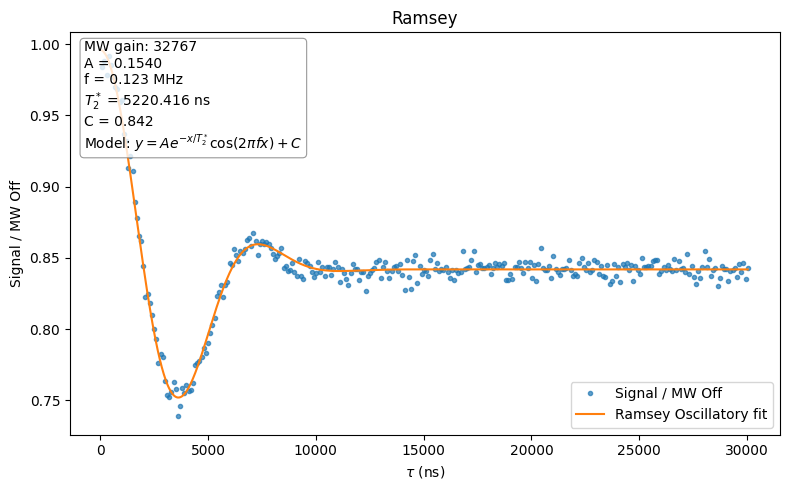

In [28]:
%run ../experiments/run/run_ramsey.py

<a id="hahn-echo"></a>
### Hahn Echo
Edit parameters in `experiments/hahn_echo.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.14 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.
[hahn_echo] Sweep: 199.992 -> 800000.000 ftns (exponential, scaling_factor=9/8)
[hahn_echo] Active transition: lower_dip | mw_fMHz=1838.1500003814697 MHz | mw_gain=32767
[hahn_echo] mw_pi2_ftsamp=117, reps=50000


100%|██████████| 2880000/2880000 [21:18<00:00, 2252.70it/s]


[hahn_echo_fine_res] Chunked run complete: {'run_id': '20260526_034203', 'output_h5_path': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\hahn_echo\\.hahn_echo_fine_res_run_20260526_034203\\hahn_echo_fine_res_20260526_034203.h5', 'output_dir': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\hahn_echo', 'plot_path': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\hahn_echo\\.hahn_echo_fine_res_run_20260526_034203\\hahn_echo_aggregated.png', 'n_chunks_completed': 7}


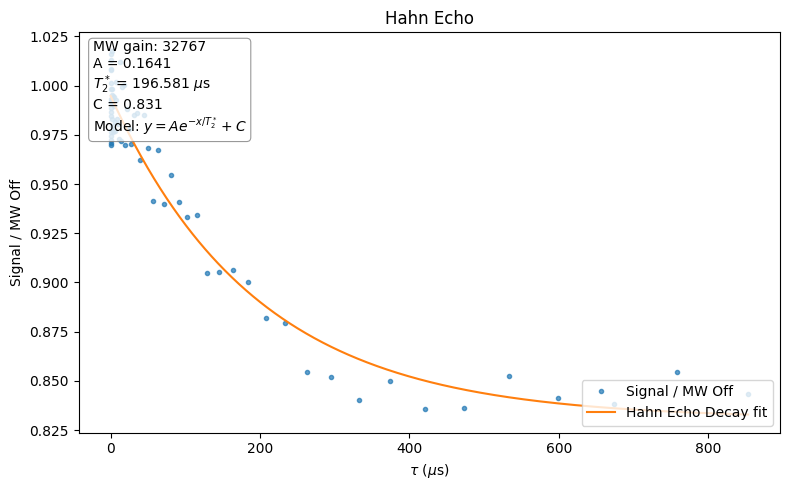

In [27]:
%run ../experiments/run/run_hahn_echo.py

<a id="t1"></a>
### T1

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.14 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.
[t1] Sweep: 0.999 -> 3000.000 us (exponential, scaling_factor=5/4)
[t1] Active transition: lower_dip | pi pulse: calibration.lower_dip.mw_pi_ftsamp=234
[t1] mw_gain=32767, reps=30000


100%|██████████| 1110000/1110000 [15:36<00:00, 1184.64it/s]


[t1_fine_res] Chunked run complete: {'run_id': '20260526_011910', 'output_h5_path': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\t1\\.t1_fine_res_run_20260526_011910\\t1_fine_res_20260526_011910.h5', 'output_dir': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\t1', 'plot_path': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\t1\\.t1_fine_res_run_20260526_011910\\t1_aggregated.png', 'n_chunks_completed': 8}


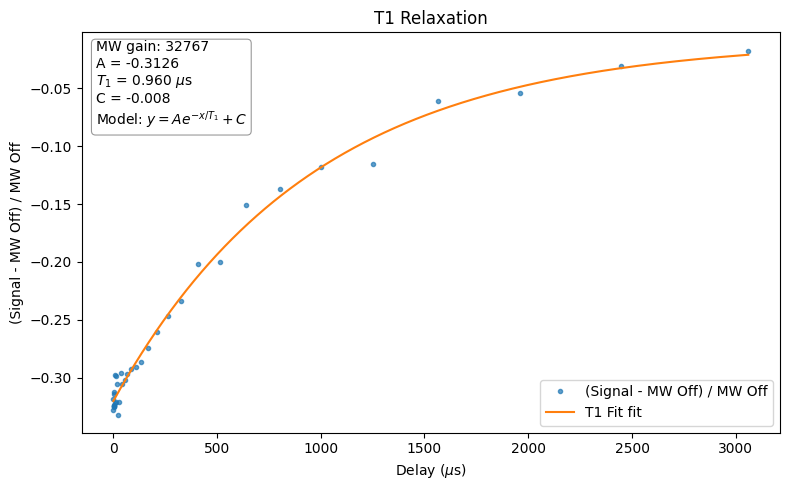

In [16]:
%run ../experiments/run/run_t1.py

<a id="cpmg"></a>
### CPMG
Edit parameters in `experiments/cpmg.py`, then run this cell.
For quick workflow validation, temporarily reduce `REPS` in the script first.

[Laser](#laser) | [Top](#top)

[config] Documented Excitation Power is 0.14 mW, ensure this aligns with measured excitation power
[config] Connecting to QICK at 192.168.3.1 ...
[config] Connected.

Requested 5000.0 to 6000.0 by 3
Instead using 5000.0 to 6016.2353515625 by 3.0517578125 in 334 steps
[cpmg] Sweep: 5000.000 -> 6016.235 ftns (delta 3.052)
[cpmg] Active transition: lower_dip | mw_fMHz=1838.1500003814697 MHz | mw_gain=32767
[cpmg] n_cpmg=32, mw_pi2_ftsamp=117, reps=2000

Requested 5000.0 to 6000.0 by 3
Instead using 5000.0 to 6016.2353515625 by 3.0517578125 in 334 steps

Requested 5000.0 to 6000.0 by 3
Instead using 5000.0 to 6016.2353515625 by 3.0517578125 in 334 steps


100%|██████████| 3340000/3340000 [20:11<00:00, 2757.23it/s]



Requested 5000.0 to 6000.0 by 3
Instead using 5000.0 to 6016.2353515625 by 3.0517578125 in 334 steps


100%|██████████| 3340000/3340000 [20:11<00:00, 2757.24it/s]



Requested 5000.0 to 6000.0 by 3
Instead using 5000.0 to 6016.2353515625 by 3.0517578125 in 334 steps


...


Requested 5000.0 to 6000.0 by 3
Instead using 5000.0 to 6016.2353515625 by 3.0517578125 in 334 steps


100%|██████████| 3340000/3340000 [20:11<00:00, 2757.23it/s]



Requested 5000.0 to 6000.0 by 3
Instead using 5000.0 to 6016.2353515625 by 3.0517578125 in 334 steps


100%|██████████| 3340000/3340000 [20:11<00:00, 2757.24it/s]


[WARN] Missing trace: signal2_cts_s (MW Off - Signal) — skipping
[WARN] Missing trace: reference2_cts_s (MW Off - Steady State) — skipping
[cpmg_xy_fine_res] Chunked run complete: {'run_id': '20260526_101237', 'output_h5_path': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\cpmg\\.cpmg_xy_fine_res_run_20260526_101237\\cpmg_xy_fine_res_20260526_101237.h5', 'output_dir': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\cpmg', 'plot_path': 'C:\\Users\\QT3 User Facility\\Documents\\qick-dawg\\data\\cpmg\\.cpmg_xy_fine_res_run_20260526_101237\\cpmg_aggregated.png', 'n_chunks_completed': 20}


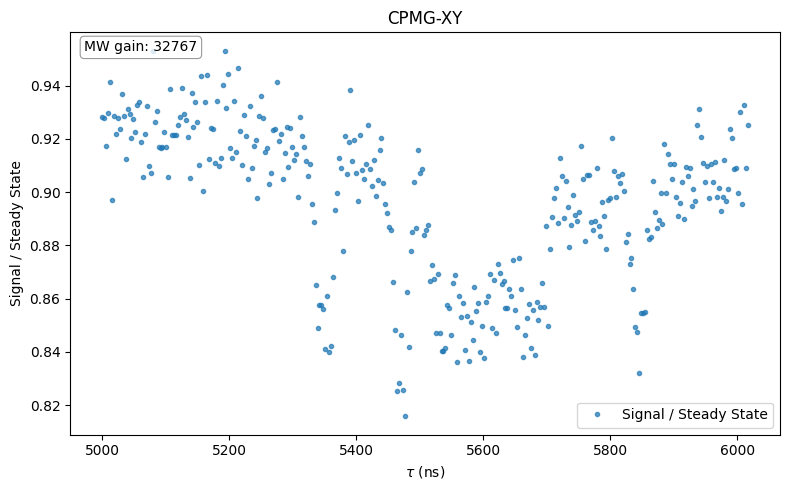

In [29]:
%run ../experiments/run/run_cpmg.py